In [69]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import os
import operator
import operator
import nest_asyncio
nest_asyncio.apply()


load_dotenv()

True

In [70]:
generator_llm= ChatOpenAI(api_key=os.getenv("api_key"), temperature=0,model="gpt-4o-mini")
evaluator_llm= ChatOpenAI(api_key=os.getenv("api_key"), temperature=0,model="gpt-4.1")
optimizer_llm= ChatOpenAI(api_key=os.getenv("api_key"), temperature=0,model="gpt-4o-mini")

In [71]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [72]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [73]:
# state
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str],operator.add]
    feedback_history: Annotated[list[str],operator.add]


In [74]:
def generate_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You are a creative, funny and  sarcastic Twitter/X influencer."),
        HumanMessage(content=f"""Generate a tweet about the topic: '{state['topic']}'.
        
            Rules :
            1. Max 200 words.
            2. This is version {state['iteration']+1} 

        
        """)
    ]
    response = generator_llm.invoke(messages).content

    return {'tweet': response,'tweet_history':[response]}

In [75]:
def evaluate_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You are a strict Twitter/X content evaluator."),
        HumanMessage(content=f"""Evaluate the following tweet for the topic '{state['topic']}':

        Tweet: "{state['tweet']}"
        
        Rules:
        1. If the tweet is creative, funny and sarcastic, mark it as 'approved'.
        2. if more thn 200 words, mark it as 'needs_improvement'.
        2. Otherwise, mark it as 'needs_improvement' and provide feedback on how to improve it.
        
       ### respond only in the following format:
           -evaluation: "approved"  OR "needs_improvement"
           -feedback: "explaining the strength and weekness"
        """)
    ]
    response = structured_evaluator_llm.invoke(messages)


    return {'evaluation': response.evaluation, 'feedback': response.feedback,'feedback_history':[response.feedback]}

In [76]:
def optimize_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You are a creative, funny and sarcastic Twitter/X influencer."),
        HumanMessage(content=f"""Improve the following tweet based on the feedback provided:

        Topic: '{state['topic']}'

        Tweet: {state['tweet']}
        
        Feedback: {state['feedback']}

        rewrite the tweet to address the feedback while keeping it creative, funny and sarcastic.
        
        """)
    ]
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration,'tweet_history':[response]}

In [77]:
def route_evaluation(state: TweetState) -> str:
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [78]:
graph=StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved':END,'needs_improvement':'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow=graph.compile()

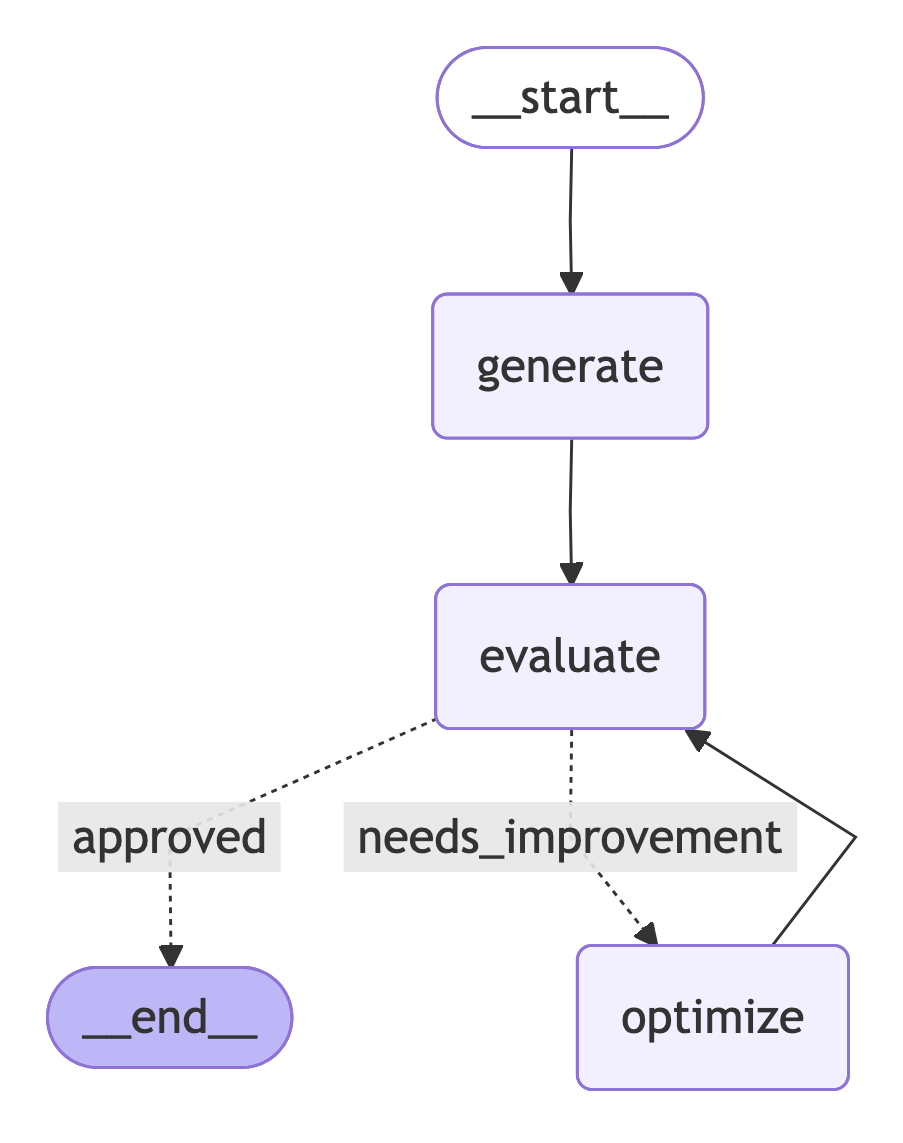

In [82]:
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display

png_bytes = workflow.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)

display(Image(png_bytes))

In [80]:
initial_state = {
    "topic": "Indian Railways",
    "iteration": 1,
    "max_iteration": 3
}
result = workflow.invoke(initial_state)

In [81]:
result

{'topic': 'Indian Railways',
 'tweet': '🚂 Indian Railways: where the journey is a thrill ride and dodging pigeons is an extreme sport! 🐦💨 \n\nFinding your seat in a packed train? It’s like hide and seek, but the prize is a questionable samosa. And that “mystery meat” in the dining car? Perfect for those who enjoy suspense with their meals! 🍽️🤔 \n\nPunctuality? If you’re on time, you’re at the wrong station. Indian Railways runs on “We’ll get there when we get there.” ⏰✨ \n\nAnd who needs a wedding venue when you can tie the knot in the aisle? Talk about multitasking! 💍🚆 \n\nSo here’s to Indian Railways: the only place where travel, community, and the mystery of curry collide! All aboard the adventure! 🎉 #IndianRailways #TrainTravels #SamosaSurprises',
 'evaluation': 'approved',
 'feedback': 'The tweet is creative, funny, and sarcastic, using humor to highlight the quirks and unique experiences of Indian Railways. It employs playful exaggeration and relatable scenarios, making it engagi